# 02 · Exploratory analysis

**Track 2 – Popularity prediction**

Starting from the cleaned table, this notebook looks at the target, the audio features and how
they relate. The aim is to decide which features go into the models and which model family suits
the data. All figures are saved to `reports/figures/` for the slides.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from scipy import stats

from src.data_prep import AUDIO_FEATURES, load_raw, PROCESSED_DIR
from src import plots

plots.set_style()
pd.set_option("display.float_format", "{:,.3f}".format)

df = pd.read_csv(PROCESSED_DIR / "spotify_clean.csv")
raw = load_raw()
print(f"{len(df):,} songs, {df['song_genre'].nunique()} genres, {df['primary_artist'].nunique():,} primary artists")

81,181 songs, 114 genres, 17,635 primary artists


## 1. The target: popularity

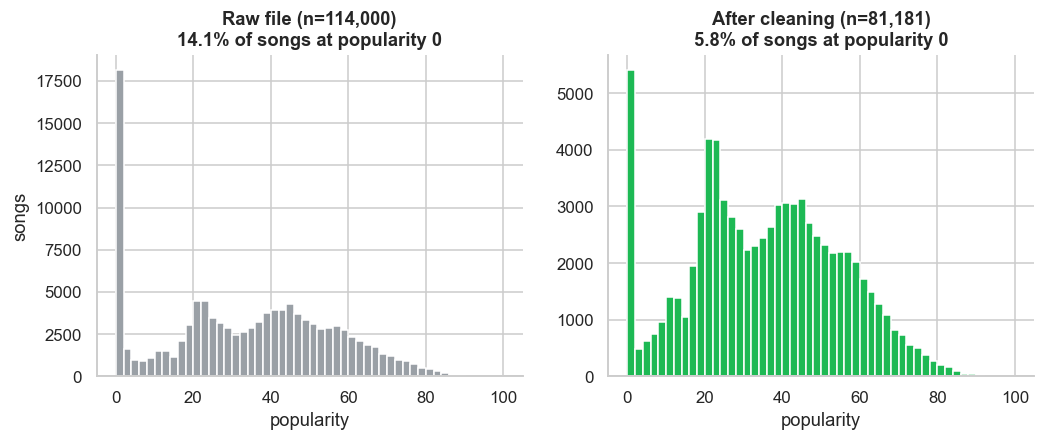

In [2]:
plots.popularity_before_after(raw, df);

In [3]:
df["popularity"].describe()

count   81,181.000
mean        35.251
std         19.418
min          0.000
25%         21.000
50%         35.000
75%         50.000
max        100.000
Name: popularity, dtype: float64

After cleaning, popularity is roughly bell-shaped around 35 with a long right tail: half of all
songs score between 21 and 50 and only about 10% reach 61 or more. The remaining bar at 0 (~6%) is
real low-play catalogue. Two things follow for modeling. First, a model that always predicts
around 35 is already off by only about 16–17 points on average, so that is the baseline any model
has to beat. Second, the tail is where the interesting songs are, and regression will tend to
under-predict it.

## 2. Audio features

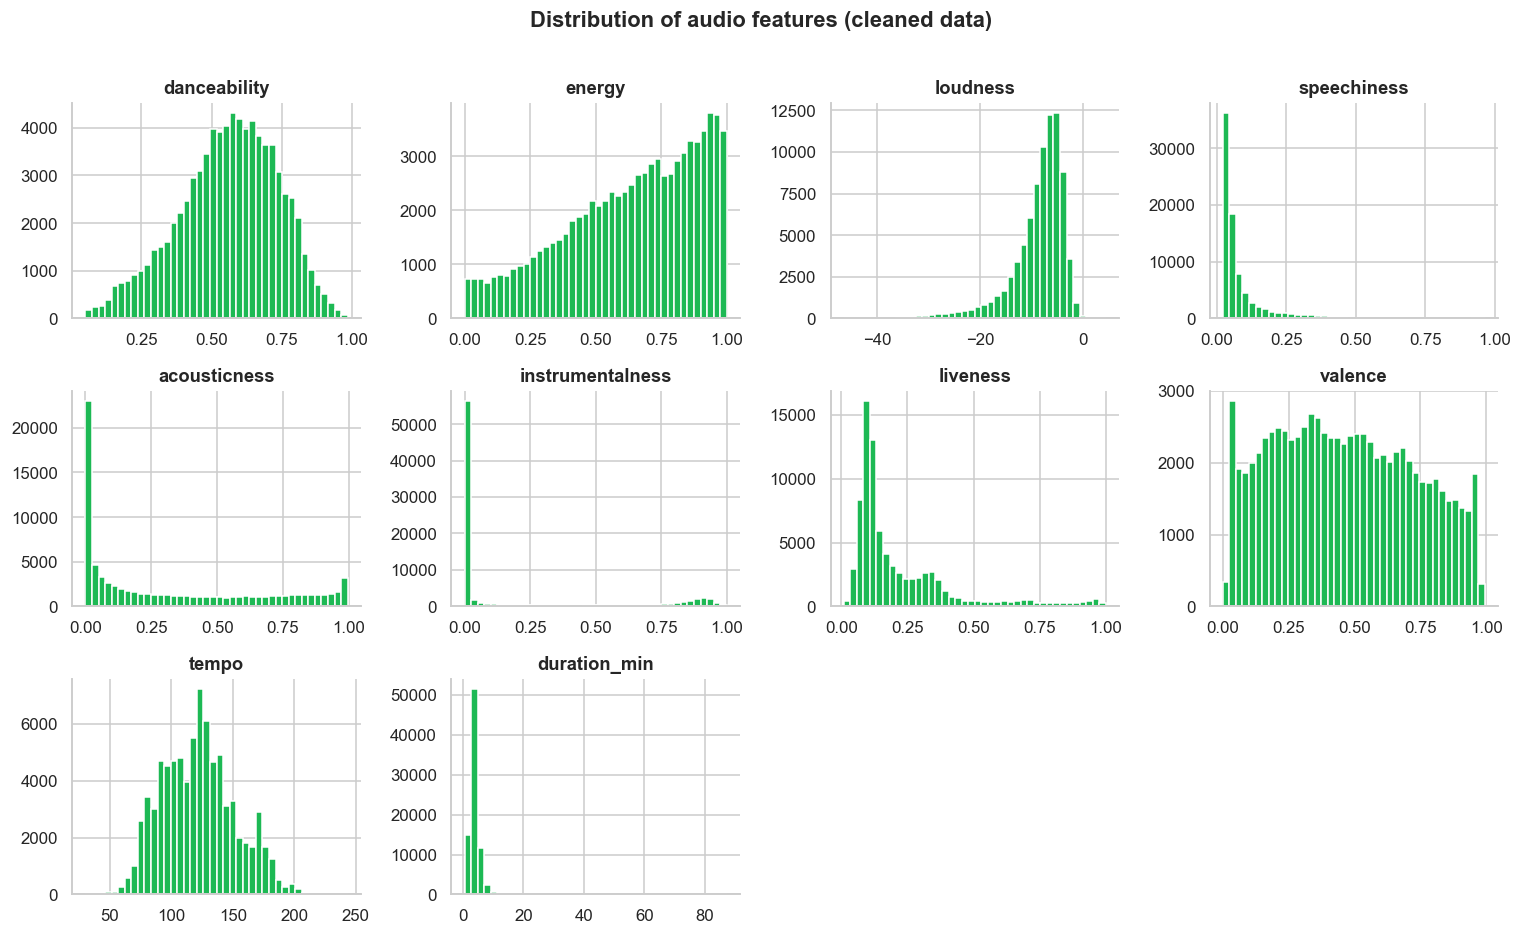

In [4]:
plots.feature_distributions(df, AUDIO_FEATURES + ["duration_min"]);

In [5]:
df[AUDIO_FEATURES + ["duration_min"]].describe().T[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
danceability,0.560,0.574,0.176,0.051,0.985
energy,0.636,0.678,0.258,0.000,1.000
loudness,-8.571,-7.258,5.257,-46.591,4.532
speechiness,0.089,0.049,0.117,0.022,0.965
acousticness,0.329,0.190,0.340,0.000,0.996
instrumentalness,0.184,0.000,0.331,0.000,1.000
liveness,0.219,0.133,0.198,0.009,1.000
valence,0.464,0.449,0.263,0.000,0.995
tempo,122.355,122.047,29.704,30.200,243.372
duration_min,3.859,3.588,1.920,0.501,87.288


Most features are far from normal. `speechiness`, `liveness` and `instrumentalness` pile up near 0
with long tails; `instrumentalness` is basically bimodal (a song either has vocals or it doesn't),
which is why we added the `is_instrumental` flag. `acousticness` is U-shaped. `loudness` is
left-skewed. Tree models are fine with this; for linear regression, scaling is the minimum and a
few of these behave better as flags than as raw values.

## 3. How the features relate to each other

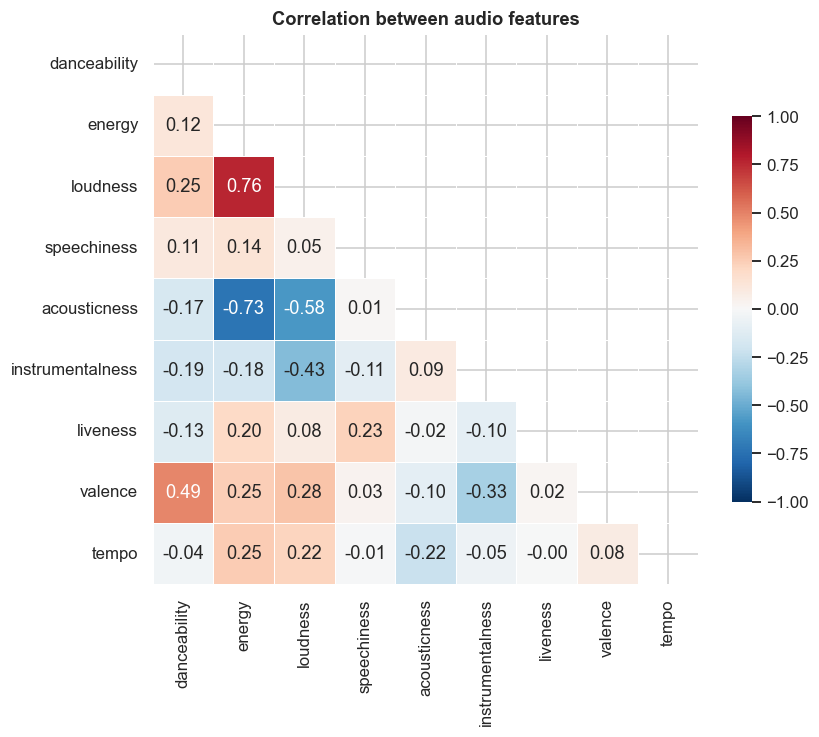

In [6]:
plots.correlation_heatmap(df, AUDIO_FEATURES);

Three pairs stand out: `energy`–`loudness` (0.76), `energy`–`acousticness` (−0.73) and
`danceability`–`valence` (0.49). Energy, loudness and acousticness largely describe one axis
("loud produced track" vs "quiet acoustic track"). In a linear model their coefficients will be
unstable and hard to read, so either use one of them or a regularised model (Ridge/Lasso). Random
forests handle it, but their importance scores will split credit between the three, which should
be kept in mind when interpreting.

## 4. Features vs popularity

In [7]:
features = AUDIO_FEATURES + ["duration_min"]
assoc = pd.DataFrame({
    "pearson": df[features].corrwith(df["popularity"]),
    "spearman": df[features].corrwith(df["popularity"], method="spearman"),
}).sort_values("pearson")
assoc

,pearson,spearman
instrumentalness,-0.188,-0.193
speechiness,-0.070,-0.092
duration_min,-0.057,-0.029
acousticness,-0.043,0.026
liveness,-0.036,-0.028
tempo,0.001,-0.001
energy,0.006,-0.034
valence,0.021,0.021
danceability,0.097,0.085
loudness,0.102,0.095


On their own, every audio feature has a weak linear relationship with popularity. The strongest is
`instrumentalness` at −0.19. Taken at face value this suggests the audio barely matters. The decile
plot below shows that the correlation is hiding the shape of the relationship.

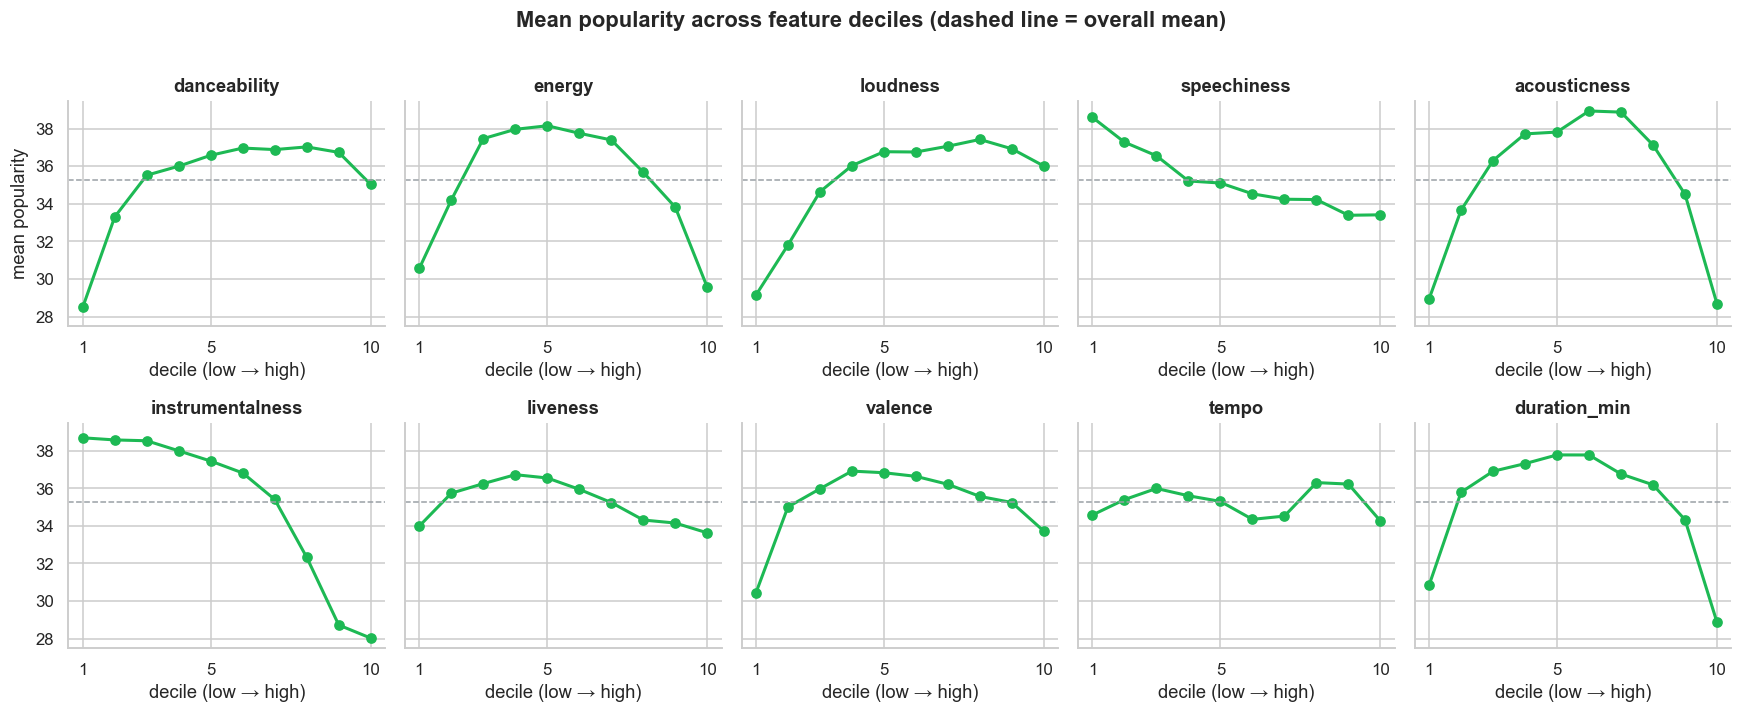

In [8]:
plots.decile_profile(df, features);

Several features have an **inverted-U** shape: `energy`, `acousticness`, `valence` and
`duration_min` have their highest popularity in the middle deciles and fall off at both extremes.
Very short and very long songs both do worse. Fully acoustic and fully electronic songs both do
worse. A correlation coefficient averages the rising and falling halves and lands near 0.
`danceability` mostly rises, with a small dip in the top decile.

The monotonic ones are `instrumentalness` (popularity drops sharply in the top three deciles, i.e.
songs without vocals), `loudness` (quiet tracks do worse) and `speechiness` (a steady small
decline). `tempo` moves within about two points across all deciles, so it shows no clear
relationship with popularity.

**For modeling:** non-linear models (decision tree, random forest, gradient boosting) should do
clearly better than plain linear regression on these features. A linear baseline is still worth
running; adding squared terms for energy, acousticness, valence and duration would be a fair test
of whether the curvature explains the gap.

## 5. Genre

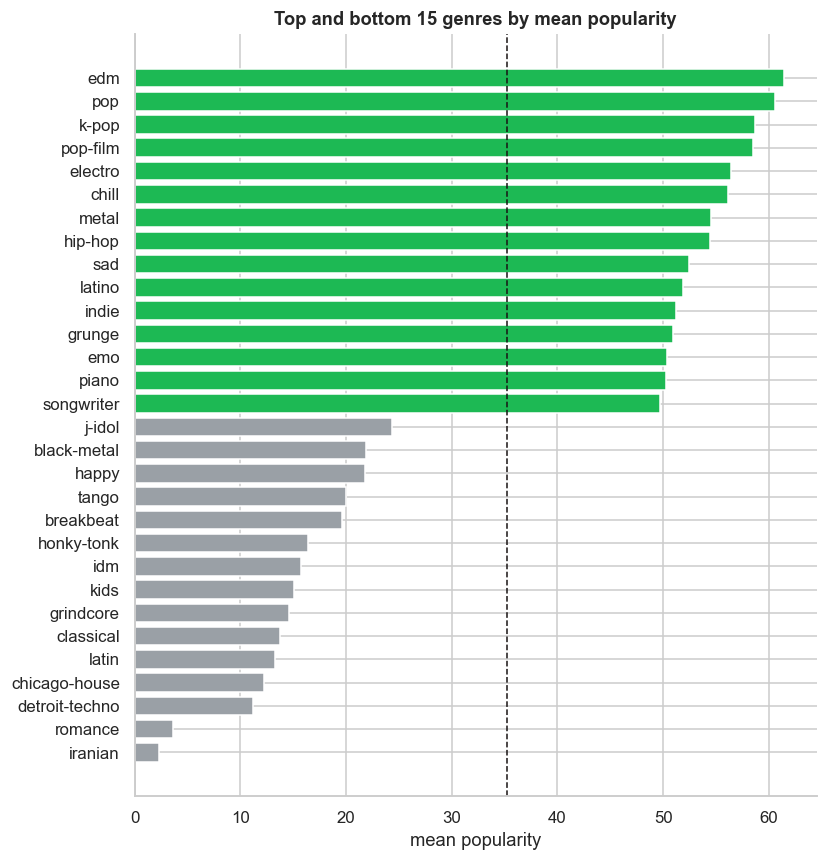

In [9]:
plots.genre_ranking(df);

In [10]:
genre_mean = df.groupby("song_genre")["popularity"].transform("mean")
eta_sq = 1 - ((df["popularity"] - genre_mean) ** 2).sum() / ((df["popularity"] - df["popularity"].mean()) ** 2).sum()
kruskal_p = stats.kruskal(*[g["popularity"] for _, g in df.groupby("song_genre")]).pvalue
print(f"share of popularity variance explained by genre alone (eta²): {eta_sq:.1%}")
print(f"Kruskal–Wallis test across genres: p = {kruskal_p:.1e}")

share of popularity variance explained by genre alone (eta²): 40.8%
Kruskal–Wallis test across genres: p = 0.0e+00


Genre is by far the strongest single signal: knowing a song's genre alone explains about **41% of
the variance** in popularity, more than all audio features combined are likely to. Mainstream
genres (EDM, pop, k-pop, hip-hop) average roughly 54–61, while genres such as iranian, romance and the
house/techno sub-genres sit near the bottom.

The very bottom needs care. Iranian and romance average under 4 with a median of 0. That is more
likely an artifact of how those 1,000-song lists were filled (old or obscure catalogue) than a
statement about the genre's audience. Latin also has a median of only 1 after cleaning. The
modeling side should keep genre as a feature, but avoid claims like "romance songs fail" in the
presentation.

## 6. Are audio features just a proxy for genre?

,overall,within genre
instrumentalness,-0.188,-0.035
speechiness,-0.070,-0.033
acousticness,-0.043,-0.017
liveness,-0.036,-0.040
tempo,0.001,-0.004
energy,0.006,-0.018
valence,0.021,-0.019
danceability,0.097,0.030
loudness,0.102,0.021


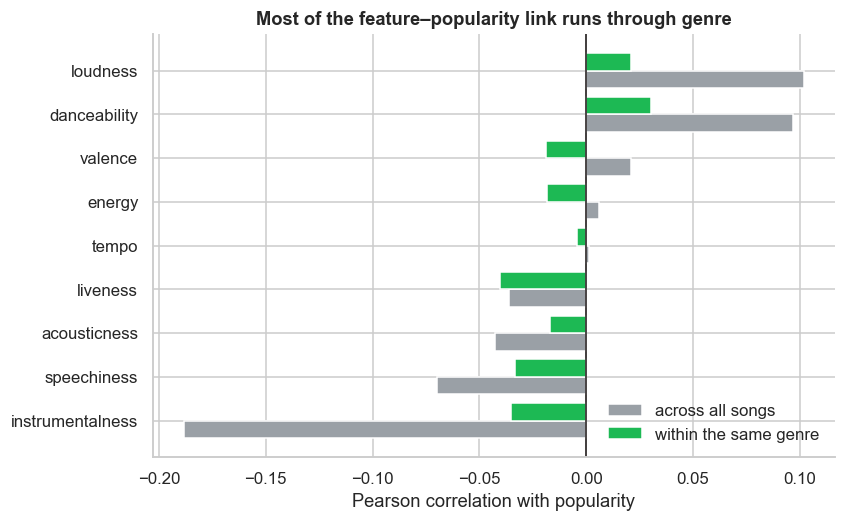

In [11]:
fig, within = plots.overall_vs_within_genre(df, AUDIO_FEATURES)
within.round(3)

This is the finding with the biggest consequence for the project. If we remove each genre's
average (compare songs only against others in the same genre), the correlations between audio
features and popularity shrink to almost nothing. Most of the link between, say, instrumentalness
and popularity exists because instrumental-heavy genres (classical, ambient, techno) are less
popular overall, not because instrumental songs lose within their own genre.

What this means for the next steps:

1. Train two versions of each model, **audio features only** and **audio + genre**. The gap
   between them is a clean way to show how much of popularity is about *what* you sound like vs
   *which scene* you're in.
2. Feature importance from the audio + genre model will be dominated by genre. Feature
   importance from the audio-only model is the one to use when advising artists on production
   choices.
3. Recommendations should be framed carefully: "within pop, X helps" needs a within-genre check,
   not just overall correlation.

## 7. Explicit content, vocals, cross-genre reach and collaborations

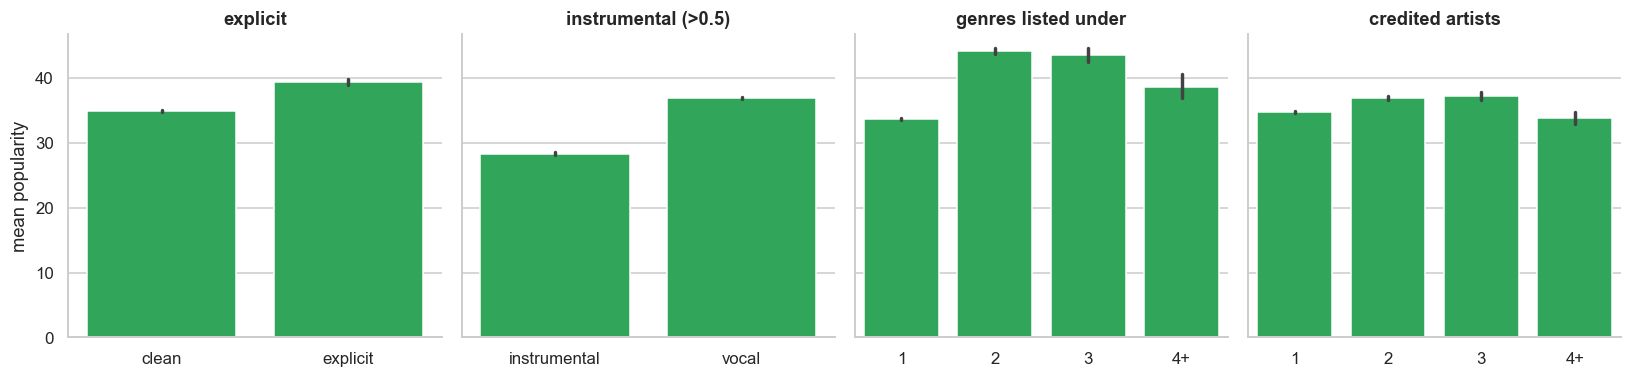

In [12]:
plots.flag_comparison(df);

In [13]:
def compare(flag):
    a, b = df.loc[df[flag] == 1, "popularity"], df.loc[df[flag] == 0, "popularity"]
    p = stats.mannwhitneyu(a, b).pvalue
    return pd.Series({"mean if 1": a.mean(), "mean if 0": b.mean(), "difference": a.mean() - b.mean(), "n if 1": len(a), "Mann-Whitney p": p})

pd.DataFrame({flag: compare(flag) for flag in ["explicit", "is_instrumental", "is_live"]}).T

,mean if 1,mean if 0,difference,n if 1,Mann-Whitney p
explicit,39.402,34.862,4.540,"6,963.000",0.000
is_instrumental,28.335,36.945,-8.610,"15,970.000",0.000
is_live,33.506,35.312,-1.806,"2,726.000",0.000


In [14]:
df.groupby(df["n_genres"].clip(upper=4))["popularity"].agg(["mean", "median", "size"])

,mean,median,size
n_genres,,,
1,33.645,32.000,68056
2,44.175,46.000,9705
3,43.488,47.000,2286
4,38.668,46.000,1134


- **Explicit** songs average about 4.5 points higher. Only 9% of songs are explicit and they
  cluster in hip-hop and similar genres, so part of this is genre again.
- **Instrumental** songs average about 8.6 points lower, the largest gap among the flags.
- **Live recordings** do slightly worse.
- **Collaborations**: two or three credited artists average about 2 points more than solo
  releases; four or more falls back. A small effect.
- **Songs listed under several genres** average about 10 points more than single-genre songs.
  This is a strong signal, but treat it with caution: a popular song is more likely to show up when
  the data was collected by searching genre by genre, so `n_genres` may partly reflect popularity
  rather than cause it. We suggest keeping it out of the main model and testing it as an extra.

## 8. What do the top songs look like?

,std. difference (top 10% − rest)
instrumentalness,-0.370
liveness,-0.220
acousticness,-0.180
duration_min,-0.130
speechiness,-0.090
tempo,-0.070
energy,0.020
valence,0.090
loudness,0.190
danceability,0.230


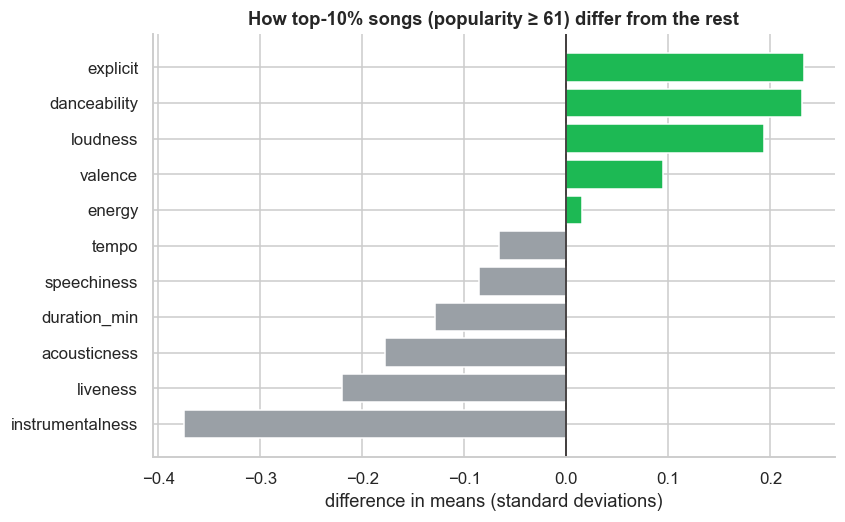

In [15]:
profile_features = AUDIO_FEATURES + ["duration_min", "explicit"]
fig, gap = plots.hits_vs_rest(df, profile_features)
gap.round(2).to_frame("std. difference (top 10% − rest)")

Compared with everything else, songs in the top 10% (popularity ≥ 61) are more danceable, louder
and more often explicit, and have noticeably less instrumental content, less live feel and less
acoustic sound. They also run a bit shorter. Tempo, energy and valence barely differ. This lines
up with the decile curves and gives the presentation a simple "what hits sound like" picture,
with the caveat from section 6 that genre mix explains much of it.

## 9. Handoff to modeling

**Data:** `data/processed/spotify_clean.csv`, one row per unique song (81,181 songs), with a fixed
`split` column (80/20, grouped by primary artist, seed 42). Use `split == "train"` for fitting and
cross-validation, and touch `split == "test"` once at the end.

**Target:** `popularity` (0–100).

**Recommended feature sets**

| set | columns |
|---|---|
| A · audio only | danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_min, explicit, mode, key, time_signature |
| B · audio + genre | set A + one-hot `song_genre` |
| optional extras | n_artists, is_instrumental, is_live, n_genres (see caveat in section 7) |

Do not use as inputs: `song_id`, `song_name`, `album_name`, `artists`, `primary_artist`. They
identify the song rather than describe it.

**Things to watch**

- Baseline to beat: predicting the training mean for every test song gives MAE ≈ 16.6. Report MAE, RMSE and R² against
  that.
- Expect tree models to beat linear regression because of the inverted-U shapes in section 4.
- For linear models, scale the features and either use one of energy/loudness/acousticness or
  regularise.
- If anyone builds an artist-level or genre-level popularity average as a feature, compute it on
  the training split only (inside each CV fold). Computing it on the full data leaks the target.
- When turning feature importance into advice for artists, use the audio-only model, and check
  that the effect holds within genre.